In [1]:
import json
import math
import argparse
import itertools

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from fintorch.enum import TimeFrame
from fintorch.exchange import ONLINE_EXCHANGE

In [3]:
START_DATE = "2023-01-01"
STOP_DATE = "2024-01-01"

SYMBOL = "BTC-USDT"
TIME_FRAME = TimeFrame.DAY1

In [4]:
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=SYMBOL, time_frame=TIME_FRAME)
sdf

,open,high,low,close,volume,trade
timestamp,,,,,,
1569456000,8428.15,8464.40,7700.67,8060.15,60065.945,449
1569542400,8061.98,8260.00,7851.94,8176.52,40034.653,504
1569628800,8178.26,8311.00,8001.14,8195.38,33820.919,756
1569715200,8199.00,8226.35,7888.98,8041.96,35966.056,1138
1569801600,8042.08,8331.89,7709.01,8285.84,54412.520,751
...,...,...,...,...,...,...
1708560000,51877.90,52130.80,50967.50,51316.90,244144.647,40806
1708646400,51316.90,51576.30,50512.70,50771.90,215474.562,19197
1708732800,50771.90,51736.60,50611.40,51602.10,104842.389,30555


In [5]:
WINDOW = 11

df = sdf.copy()
df["roc"] = df.close / df.open - 1
df["tr"] = df.high / df.low - 1
df["vpt"] = df.volume / df.trade

df

,open,high,low,close,volume,trade,roc,tr,vpt
timestamp,,,,,,,,,
1569456000,8428.15,8464.40,7700.67,8060.15,60065.945,449,-0.043663,0.099177,133.777160
1569542400,8061.98,8260.00,7851.94,8176.52,40034.653,504,0.014207,0.051969,79.433835
1569628800,8178.26,8311.00,8001.14,8195.38,33820.919,756,0.002093,0.038727,44.736665
1569715200,8199.00,8226.35,7888.98,8041.96,35966.056,1138,-0.019154,0.042765,31.604619
1569801600,8042.08,8331.89,7709.01,8285.84,54412.520,751,0.030311,0.080799,72.453422
...,...,...,...,...,...,...,...,...,...
1708560000,51877.90,52130.80,50967.50,51316.90,244144.647,40806,-0.010814,0.022824,5.983058
1708646400,51316.90,51576.30,50512.70,50771.90,215474.562,19197,-0.010620,0.021056,11.224387
1708732800,50771.90,51736.60,50611.40,51602.10,104842.389,30555,0.016352,0.022232,3.431268


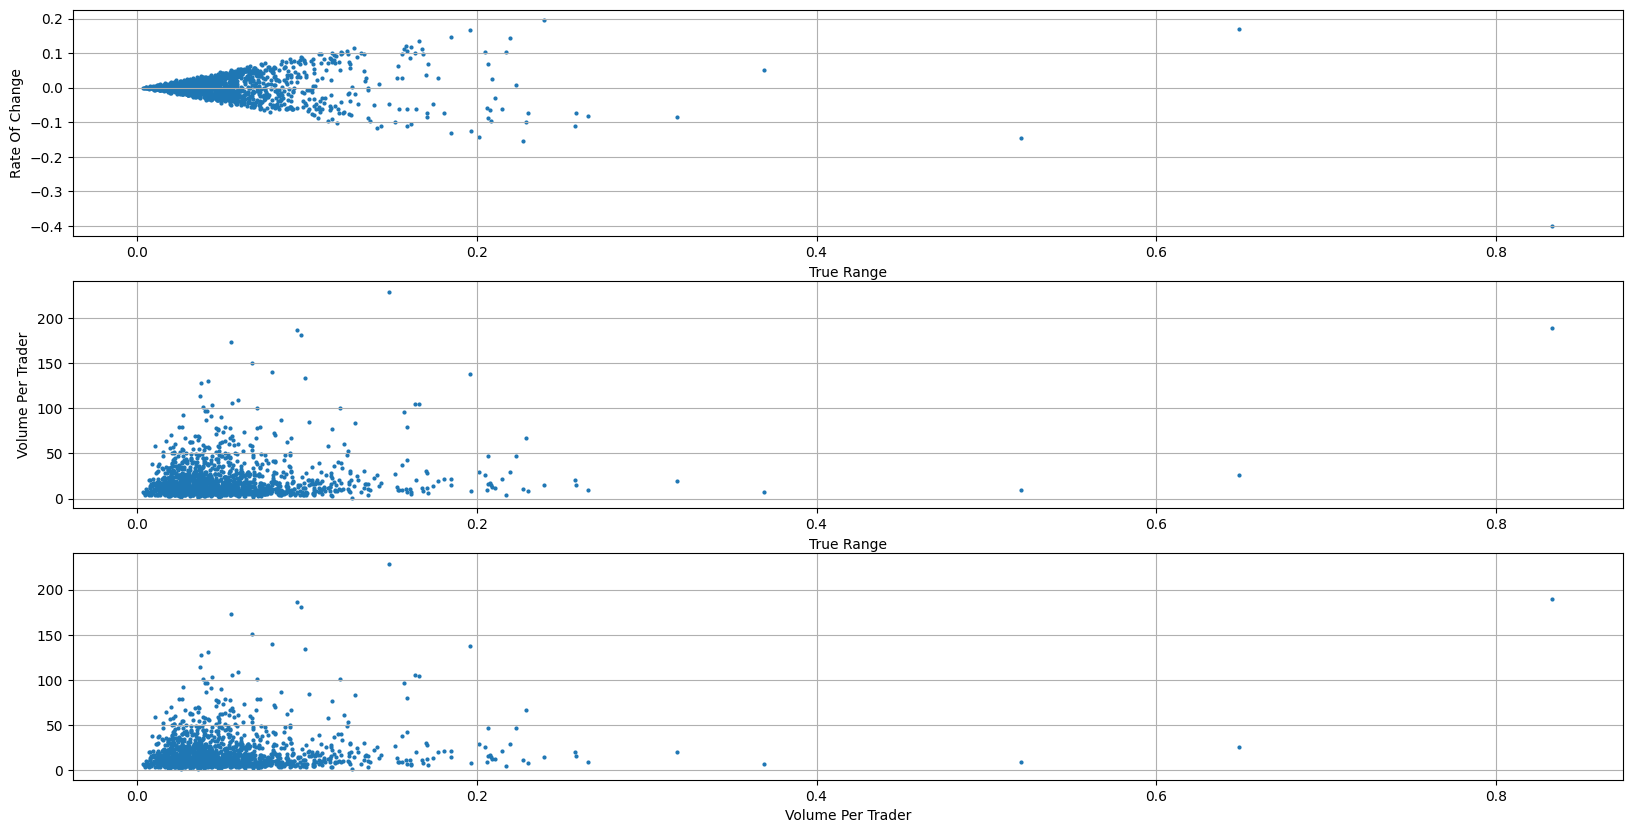

In [6]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(20, 10))

axs[0].scatter(x=df.tr, y=df.roc, s=4)
axs[0].set_xlabel("True Range")
axs[0].set_ylabel("Rate Of Change")
axs[0].grid()

axs[1].scatter(x=df.tr, y=df.vpt, s=4)
axs[1].set_xlabel("True Range")
axs[1].set_ylabel("Volume Per Trader")
axs[1].grid()

axs[2].scatter(x=df.tr, y=df.vpt, s=4)
axs[2].set_xlabel("Volume Per Trader")
axs[2].set_ylabel("")
axs[2].grid()